# Deformer — with Grasp Intensity Head

**Original architecture fully preserved.** The following additions were made:

| What | Where | Purpose |
|---|---|---|
| `compute_grasp_intensity_geometric()` | standalone function | Derives a 0→1 pseudo-label from keypoints — no extra annotation needed |
| `GraspIntensityHead` (2-layer MLP + Sigmoid) | inside `DFM.__init__()` | Learned scalar output ∈ (0, 1) |
| Updated `DFM.forward()` | returns 4 values | adds `grasp_intensity` |
| Updated `Deformer.forward()` | returns 5 values | threads `grasp_intensity` through |
| Updated training loop | grasp MSE loss × 0.3 | self-supervised grasp signal |
| Updated inference | side-by-side plot | keypoints + colour intensity bar |

**Grasp intensity scale:** `0.0` = fully open hand &nbsp;|&nbsp; `1.0` = fully closed / tight grasp

## 1 · Imports & Drive Mount

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from google.colab import drive

import zipfile
import pickle
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os, json, glob
import re

In [2]:
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/Agam_Deformer

Mounted at /content/gdrive
/content/gdrive/MyDrive/Agam_Deformer


## 2 · Backbone Modules *(unchanged)*

`PatchEmbedding` → `PositionalEncoding` → `SpatialTransformer` → `TemporalTransformer`

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, out_channels=128, patch_size=4):
        super().__init__()
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
        self.conv_model = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.conv_model(x)            # (N, C_out, H_out, W_out)
        N, C_out, H_out, W_out = x.shape
        x = x.flatten(2).transpose(1, 2)  # (N, H_out*W_out, C_out)
        return x


class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html
        self.position = nn.Parameter(torch.randn(1, max_len, d_model))

    def forward(self, x):
        x = x + self.position[:, :x.size(1), :]
        return x


class SpatialTransfomer(nn.Module):
    def __init__(self, d_model, img_size=128, patch_size=4):
        super().__init__()
        self.patch = PatchEmbedding(3, d_model)
        num_patches = (img_size // patch_size) ** 2
        self.position = PositionalEncoding(num_patches, d_model)
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=3)

    def forward(self, x):
        x = self.patch(x)
        x = self.position(x)
        x = self.encoder(x)
        return x.mean(dim=1)   # (B, d_model) — global per-frame token


class TemporalTransfomer(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        self.position = PositionalEncoding(max_len, d_model)
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=3)

    def forward(self, x):
        x = self.position(x)
        x = self.encoder(x)
        return x   # (B, T, d_model)


print('Backbone modules defined.')

Backbone modules defined.


## 3 · Geometric Grasp Intensity Helper *(NEW)*

Converts raw 3-D keypoints into a **0 → 1 pseudo-label** with no extra annotation.

```
Open hand  → fingertips far from palm centre  → intensity near 0
Closed fist → fingertips close to palm centre → intensity near 1
```

The distance is normalised by wrist-to-middle-MCP length so the score is **pose-invariant** (independent of how close the hand is to the camera).

In [4]:
def compute_grasp_intensity_geometric(kp):
    """
    Derive a grasp-intensity pseudo-label purely from 3-D keypoints.

    Parameters
    ----------
    kp : Tensor (B, 21, 3)
        Predicted or ground-truth 3-D keypoints in the MANO / DexYCB layout:
          0         wrist
          1-4       thumb  CMC / MCP / IP  / TIP
          5-8       index  MCP / PIP / DIP / TIP
          9-12      middle MCP / PIP / DIP / TIP
          13-16     ring   MCP / PIP / DIP / TIP
          17-20     pinky  MCP / PIP / DIP / TIP

    Returns
    -------
    intensity : Tensor (B,) in [0, 1]
        0 = fully open hand
        1 = fully closed / tight grasp
    """
    fingertip_idx = [4, 8, 12, 16, 20]      # thumb … pinky tips
    palm_idx      = [0, 5, 9, 13, 17]       # wrist + all 5 MCPs

    palm_center = kp[:, palm_idx, :].mean(dim=1, keepdim=True)   # (B, 1, 3)
    fingertips  = kp[:, fingertip_idx, :]                         # (B, 5, 3)

    # Euclidean distance from each fingertip to palm centre
    distances = torch.norm(fingertips - palm_center, dim=-1)      # (B, 5)

    # Hand scale = wrist (0) → middle MCP (9)
    hand_scale = torch.norm(kp[:, 9, :] - kp[:, 0, :], dim=-1, keepdim=True) + 1e-6

    # Normalised, scale-free distance
    mean_dist = (distances / hand_scale).mean(dim=1)              # (B,)

    # Empirical range: open ≈ 2.0, closed ≈ 0.5
    # Map [2.0, 0.5] → [0, 1] and clamp for safety
    intensity = torch.clamp((2.0 - mean_dist) / 1.5, 0.0, 1.0)
    return intensity


print('compute_grasp_intensity_geometric() defined.')

compute_grasp_intensity_geometric() defined.


## 4 · DFM — Dynamic Fusion Module *(GraspIntensityHead added)*

The only change from the original is a small **2-layer MLP** called `grasp_head` bolted onto the same cross-attended global feature `res` that already drives `pose_classifier` and `motion_classifier`.

```
res  (B, d_model)
 ├─► pose_classifier   → (B, 21, 3)        [unchanged]
 ├─► motion_classifier → fm, bm            [unchanged]
 └─► grasp_head        → (B,)  ∈ (0, 1)   [NEW]
```

In [5]:
class DFM(nn.Module):
    """
    Dynamic Fusion Module.
    New output: grasp_intensity (B,) in [0, 1]
    """
    def __init__(self, d_model, num_keypoints, hand_d=2):
        super().__init__()
        self.num_keypoints = num_keypoints
        self.hand_d        = hand_d

        self.query             = nn.Parameter(torch.randn(1, 1, d_model))
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html
        self.cross_attention   = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=8, batch_first=True
        )
        self.pose_classifier   = nn.Linear(d_model, num_keypoints * 3)
        self.motion_classifier = nn.Linear(d_model, num_keypoints * 3 * 2)

        # ── NEW: Grasp Intensity Head ────────────────────────────────────────
        # 2-layer MLP reading from the same global cross-attended feature.
        # Sigmoid guarantees output is strictly in (0, 1).
        self.grasp_head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()    # ← output ∈ (0, 1)
        )
        # ────────────────────────────────────────────────────────────────────

    def forward(self, x):
        batch = x.shape[0]

        # Cross-attention: single learnable query attends to all temporal tokens
        q = self.query.expand(batch, -1, -1)          # (B, 1, d_model)
        res, _ = self.cross_attention(query=q, key=x, value=x)
        res    = res.squeeze(1)                        # (B, d_model)

        # Pose & motion predictions (unchanged)
        pose_pred   = self.pose_classifier(res).view(batch, self.num_keypoints, 3)
        motion_pred = self.motion_classifier(res)
        fm = motion_pred[:, :self.num_keypoints * 3].view(batch, self.num_keypoints, 3)
        bm = motion_pred[:, self.num_keypoints * 3:].view(batch, self.num_keypoints, 3)

        # ── NEW ──────────────────────────────────────────────────────────────
        grasp_intensity = self.grasp_head(res).squeeze(-1)   # (B,)
        # ────────────────────────────────────────────────────────────────────

        return pose_pred, fm, bm, grasp_intensity


print('DFM defined.')

DFM defined.


## 5 · Deformer — Full Model *(grasp_intensity threaded through)*

The only change is unpacking and returning the new `grasp_intensity` value.

**New return signature:**
```python
kp_pred, pose_pred, fm, bm, grasp_intensity = model(images)
#                              └── Tensor (B,) in [0, 1]  ← NEW
```

In [6]:
class Deformer(nn.Module):
    """Spatial encoder + Temporal encoder + Query-based fusion + Prediction"""

    def __init__(self, d_model, num_keypoints):
        super().__init__()
        self.st         = SpatialTransfomer(d_model)
        self.tt         = TemporalTransfomer(d_model)
        self.dfm        = DFM(d_model, num_keypoints)
        self.confidence = nn.Linear(d_model, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape

        # 1. Spatial encoding — process all frames independently
        x_reshaped      = x.view(B * T, C, H, W)
        spacial_feature = self.st(x_reshaped)           # (B*T, d_model)
        spacial_feature = spacial_feature.view(B, T, -1) # (B, T, d_model)

        # 2. Temporal encoding — model motion across frames
        temporal_feature = self.tt(spacial_feature)      # (B, T, d_model)

        # 3. Dynamic Fusion — cross-attention + predictions
        # ── MODIFIED: unpack grasp_intensity ──────────────────────────────
        pose_pred, fm, bm, grasp_intensity = self.dfm(temporal_feature)
        # ──────────────────────────────────────────────────────────────────

        # 4. Deform pose toward t+1 and t-1
        pose_forward  = pose_pred + fm
        pose_backward = pose_pred + bm
        poses = torch.stack(
            [pose_pred, pose_forward, pose_backward], dim=1
        )  # (B, 3, num_keypoints, 3)

        # 5. Confidence-weighted fusion of the three pose candidates
        temporal_mean = temporal_feature.mean(dim=1)                        # (B, d_model)
        conf_input    = temporal_mean.unsqueeze(1).expand(-1, 3, -1)        # (B, 3, d_model)
        conf          = torch.softmax(self.confidence(conf_input), dim=1)   # (B, 3, 1)
        conf          = conf.unsqueeze(-1).expand_as(poses)                 # (B, 3, K, 3)
        kp_pred       = (conf * poses).sum(dim=1)                           # (B, K, 3)

        # ── MODIFIED: return grasp_intensity ──────────────────────────────
        return kp_pred, pose_pred, fm, bm, grasp_intensity
        # ──────────────────────────────────────────────────────────────────


print('Deformer defined.')

Deformer defined.


## 6 · Data Setup — Extract DexYCB Archives

In [7]:
import os
os.makedirs('/content/DexYCB', exist_ok=True)

base = '/content/gdrive/MyDrive/Agam_Deformer/data'

# Extract calibration and models once (unchanged)
print('Extracting calibration and models...')
!tar -xzf "{base}/Copy of calibration.tar.gz" -C /content/DexYCB/
!tar -xzf "{base}/Copy of models.tar.gz"      -C /content/DexYCB/

# Extract all subjects dynamically — no need to list them one by one
import glob
subject_archives = sorted(glob.glob(f'{base}/Copy of 2020*-subject-*.tar.gz'))
print(f'Found {len(subject_archives)} subject archives')

for archive in subject_archives:
    print(f'Extracting {os.path.basename(archive)}...')
    os.system(f'tar -xzf "{archive}" -C /content/DexYCB/')

print('Done.')

Extracting calibration and models...
Found 7 subject archives
Extracting Copy of 20200709-subject-01.tar.gz...
Extracting Copy of 20200813-subject-02.tar.gz...
Extracting Copy of 20200820-subject-03.tar.gz...
Extracting Copy of 20200903-subject-04.tar.gz...
Extracting Copy of 20200908-subject-05.tar.gz...
Extracting Copy of 20201002-subject-08.tar.gz...
Extracting Copy of 20201015-subject-09.tar.gz...
Done.


## 7 · SeqDataset — Sequential Frame Loader *(unchanged)*

In [10]:
class SeqDataset(Dataset):
    """Provides sequences of seq_len (default 7) consecutive frames + annotations."""

    def __init__(self, root, split='train', seq_len=7, gap=1, transform=None):
        self.root      = root
        self.seq_len   = seq_len   # T=7 per Deformer paper
        self.gap       = gap
        self.transform = transform
        self.samples   = []
        self.create_samples()
        print(f'{split} data: {len(self.samples)} sequences')

    def create_samples(self):
    # NEW: loop through subject folders first
      subject_dirs = sorted(glob.glob(os.path.join(self.root, '*')))
      for subject_dir in subject_dirs:
          session_dirs = sorted(glob.glob(os.path.join(subject_dir, '*')))
          for session_dir in session_dirs:
              camera_dirs = sorted(glob.glob(os.path.join(session_dir, '*')))
              for cam_dir in camera_dirs:
                  frames     = sorted(glob.glob(os.path.join(cam_dir, 'color_*.jpg')))
                  num_frames = len(frames)
                  if num_frames < self.seq_len * self.gap:
                      continue
                  window = self.seq_len * self.gap
                  for start in range(0, num_frames - window + 1, self.gap):
                      indices         = [start + i * self.gap for i in range(self.seq_len)]
                      selected_frames = [frames[i] for i in indices]
                      self.samples.append((cam_dir, selected_frames))

    def load_annotation(self, frame_path):
        anno_path = frame_path.replace('color_', 'labels_').replace('.jpg', '.npz')
        if os.path.exists(anno_path):
            data = np.load(anno_path, allow_pickle=True)
            return data['joint_3d'][0].astype(np.float32)   # (21, 3)
        return np.zeros((21, 3), dtype=np.float32)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cap_dir, frame_paths = self.samples[idx]
        images, keypoints    = [], []

        for fp in frame_paths:
            img = Image.open(fp).convert('RGB')
            if self.transform:
                img = self.transform(img)
            images.append(img)
            keypoints.append(torch.tensor(self.load_annotation(fp)))

        images    = torch.stack(images,    dim=0)   # (T, 3, H, W)
        keypoints = torch.stack(keypoints, dim=0)   # (T, 21, 3)
        mid       = self.seq_len // 2

        return {
            'images':    images,
            'kp_target': keypoints[mid],
            'kp_seq':    keypoints,
        }


print('SeqDataset defined.')

SeqDataset defined.


## 8 · Build DataLoader & Verify Batch Shapes

In [11]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = SeqDataset(
    root      = '/content/DexYCB',
    split     = 'train',
    seq_len   = 7,
    gap       = 1,
    transform = transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = 4,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True
)

# Quick shape check
batch = next(iter(train_loader))
print('images shape:  ', batch['images'].shape)     # (4, 7, 3, 128, 128)
print('kp_target shape:', batch['kp_target'].shape) # (4, 21, 3)
print(f'Total samples: {len(train_dataset)} | Batches/epoch: {len(train_loader)}')

train data: 372704 sequences
images shape:   torch.Size([4, 7, 3, 128, 128])
kp_target shape: torch.Size([4, 21, 3])
Total samples: 372704 | Batches/epoch: 93176


## 9 · Loss Function *(unchanged)*

In [12]:
def maxmse_loss(prediction, target):
    """Max-MSE loss from Equation (5) of the Deformer paper."""
    square_error = ((prediction - target) ** 2).sum(dim=-1)  # sum over xyz
    numerator    = (square_error ** 2).sum(dim=-1)
    denominator  = square_error.sum(dim=-1) + 1e-8
    return (numerator / denominator).mean()


print('maxmse_loss defined.')

maxmse_loss defined.


## 10 · Model, Optimiser & Checkpoint Setup

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', 'Go to Runtime → Change runtime type → T4 GPU'

model = Deformer(d_model=256, num_keypoints=21)
model.to(device)
print('Parameters:', sum(p.numel() for p in model.parameters()))

checkpoint_dir = '/content/gdrive/MyDrive/Agam_Deformer/checkpoints_dexycb'
os.makedirs(checkpoint_dir, exist_ok=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# Resume logic
checkpoints = sorted(
    glob.glob(os.path.join(checkpoint_dir, 'all_subjects_epoch_*.pth')),
    key=lambda x: int(re.search(r'epoch_(\d+)', x).group(1))
)
start_epoch = 0

if checkpoints:
    latest = checkpoints[-1]
    print(f"Loading checkpoint: {latest}")
    ckpt = torch.load(latest, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt['epoch']
    print(f'Resuming from epoch {start_epoch}')
else:
    print('No checkpoint found. Starting from scratch.')

Parameters: 11136831
No checkpoint found. Starting from scratch.


## 11 · Training Loop *(grasp loss added)*

Total loss = `maxmse(kp_pred, target)` + `0.5 × maxmse(pose_pred, target)` + **`0.3 × mse(grasp_intensity, grasp_pseudo_label)`**

The `0.3` weight keeps the grasp signal from dominating pose accuracy. Increase it if you want the model to prioritise grasp precision.

In [ ]:
num_epochs = 10

for epoch in range(start_epoch, num_epochs):
    model.train()
    total_loss, total_grasp_loss, num_batches = 0.0, 0.0, 0

    for batch in train_loader:
        images    = batch['images'].to(device)
        kp_target = batch['kp_target'].to(device)

        # Forward pass — unpack all 5 outputs
        kp_pred, pose_pred, fm, bm, grasp_intensity = model(images)

        # Original pose losses (unchanged)
        loss  = maxmse_loss(kp_pred,    kp_target)
        loss += 0.5 * maxmse_loss(pose_pred, kp_target)

        # ── NEW: Grasp intensity loss ─────────────────────────────────────
        # Pseudo-label from ground-truth keypoints — no extra annotation.
        grasp_target = compute_grasp_intensity_geometric(kp_target)   # (B,)
        grasp_loss   = F.mse_loss(grasp_intensity, grasp_target)
        loss        += 0.3 * grasp_loss
        # ─────────────────────────────────────────────────────────────────

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss       += loss.item()
        total_grasp_loss += grasp_loss.item()
        num_batches      += 1

    avg_loss       = total_loss       / num_batches
    avg_grasp_loss = total_grasp_loss / num_batches
    scheduler.step(avg_loss)

    print(
        f'Epoch {epoch+1:02d}/{num_epochs} | '
        f'Loss: {avg_loss:.6f} | '
        f'Grasp Loss: {avg_grasp_loss:.6f} | '
        f'LR: {optimizer.param_groups[0]["lr"]:.2e}'
    )

    torch.save({
        'epoch':                epoch + 1,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss':                 avg_loss,
        'num_keypoints':        21,
        'd_model':              256,
    }, os.path.join(checkpoint_dir, f'all_subjects_checkpoint_epoch_{epoch+1}.pth'))

print('Training complete.')

## 12 · Inference *(keypoints + grasp intensity bar)*

The plot shows two panels:
- **Left** — predicted 3-D keypoints projected onto the middle frame
- **Right** — horizontal colour bar: green = open hand, red = tight grasp

In [ ]:
def run_colab_inference(checkpoint_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    ck    = torch.load(checkpoint_path, map_location=device)
    model = Deformer(d_model=ck['d_model'], num_keypoints=ck['num_keypoints'])
    model.load_state_dict(ck['model_state_dict'])
    model.to(device).eval()
    print(f'Loaded epoch {ck["epoch"]}, loss {ck["loss"]:.6f}')

    # Grab 7 consecutive frames
    frames = sorted(glob.glob(
    '/content/DexYCB/20200709-subject-01/20200709_141841/932122062010/color_*.jpg'
    ))[50:57]
    tfm = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    images = torch.stack([tfm(Image.open(f).convert('RGB')) for f in frames])
    images = images.unsqueeze(0).to(device)   # (1, 7, 3, 128, 128)

    with torch.no_grad():
        kp_pred, _, _, _, grasp_intensity = model(images)

    kp_3d     = kp_pred[0].cpu().numpy()   # (21, 3)
    intensity = grasp_intensity[0].item()  # scalar in [0, 1]

    # Project keypoints to 2D
    K       = np.array([[500, 0, 320], [0, 500, 240], [0, 0, 1]], dtype=np.float32)
    kp_proj = kp_3d @ K.T
    kp_2d   = kp_proj[:, :2] / kp_proj[:, 2:3]

    # ── Plot ────────────────────────────────────────────────────────────────
    mid_frame = np.array(Image.open(frames[3]).convert('RGB'))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: keypoints overlay
    axes[0].imshow(mid_frame)
    axes[0].scatter(kp_2d[:, 0], kp_2d[:, 1], c='lime', s=50, zorder=5)
    axes[0].set_title(f'Predicted Keypoints — Epoch {ck["epoch"]}')
    axes[0].axis('off')

    # Right: grasp intensity bar  (green=open, red=grasping)
    bar_color = plt.cm.RdYlGn(1.0 - intensity)
    axes[1].barh(['Grasp\nIntensity'], [intensity], color=bar_color, height=0.4)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Intensity  (0 = open  →  1 = fully grasped)')
    axes[1].set_title(f'Grasp Intensity: {intensity:.3f}')
    axes[1].axvline(x=0.5, color='grey', linestyle='--', linewidth=0.8)
    axes[1].text(
        min(intensity + 0.02, 0.95), 0,
        f'{intensity:.3f}', va='center', fontsize=12, fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    label = 'GRASPING' if intensity > 0.5 else 'OPEN / RELAXED'
    print(f'\nGrasp Intensity Score: {intensity:.4f}  ({label})')
    # ────────────────────────────────────────────────────────────────────────


run_colab_inference(
    '/content/gdrive/MyDrive/Agam_Deformer/checkpoints_dexycb/Copy_of_checkpoint_epoch_21.pth'
)

## 13 · Sanity Check *(no GPU required)*

Verifies that all output shapes are correct and `grasp_intensity` is in `[0, 1]`.

In [ ]:
model_test = Deformer(d_model=256, num_keypoints=21)
dummy      = torch.randn(2, 7, 3, 128, 128)   # (B, T, C, H, W)

kp, pose, fm, bm, grasp = model_test(dummy)

print('kp shape:       ', kp.shape)     # expect (2, 21, 3)
print('grasp shape:    ', grasp.shape)  # expect (2,)
print('grasp values:   ', grasp.detach().numpy().round(4))  # two scalars in (0,1)

assert kp.shape    == (2, 21, 3), 'kp shape mismatch'
assert grasp.shape == (2,),       'grasp shape mismatch'
assert (grasp >= 0).all() and (grasp <= 1).all(), 'grasp out of [0,1]'

print('\n✅ All checks passed.')

kp shape:        torch.Size([2, 21, 3])
grasp shape:     torch.Size([2])
grasp values:    [0.5094 0.5055]

✅ All checks passed.


Model loaded — epoch 21


<IPython.core.display.Javascript object>

Waiting for webcam to initialise...
Webcam ready. Capturing frames...

Buffering... 1/7
Buffering... 2/7
Buffering... 3/7
Buffering... 4/7
Buffering... 5/7
Buffering... 6/7


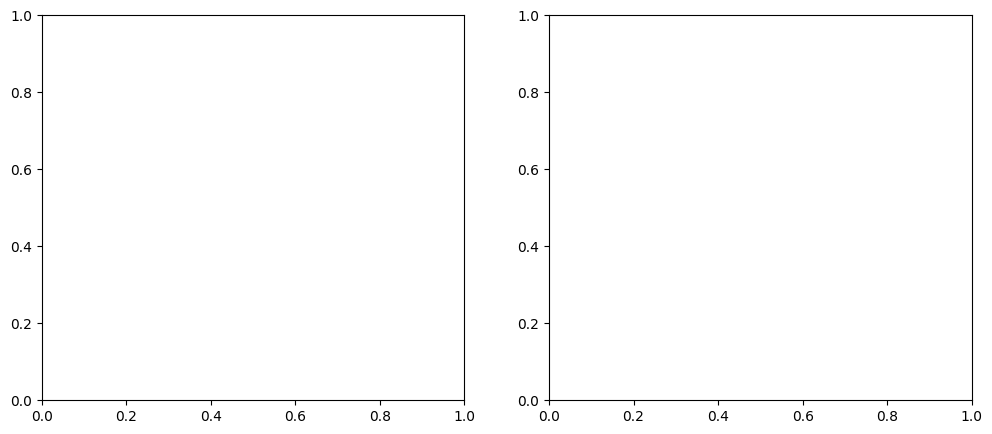

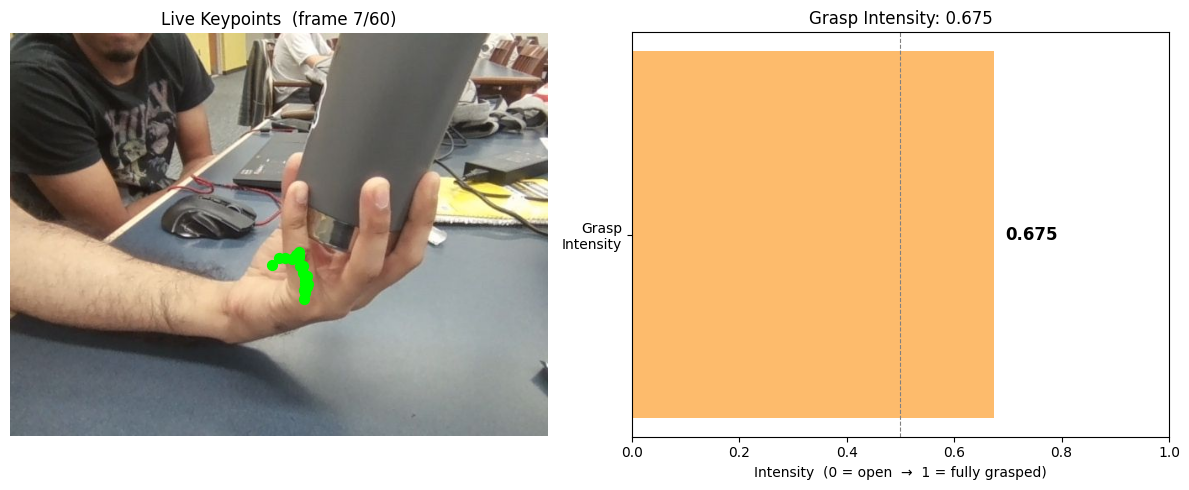

Frame 007 | Intensity: 0.6746 | GRASPING


<Figure size 640x480 with 0 Axes>

Frame 008 | Intensity: 0.6741 | GRASPING


<Figure size 640x480 with 0 Axes>

Frame 009 | Intensity: 0.6738 | GRASPING


...

<Figure size 640x480 with 0 Axes>

Frame 059 | Intensity: 0.6710 | GRASPING


<Figure size 640x480 with 0 Axes>

Frame 060 | Intensity: 0.6711 | GRASPING


<IPython.core.display.Javascript object>

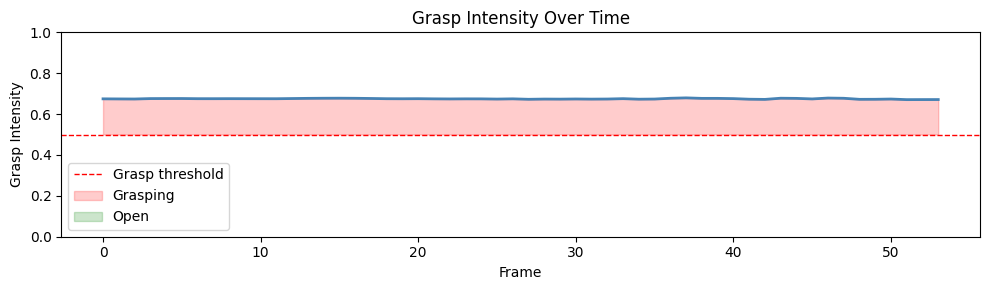


Session complete.


In [ ]:
def run_live_grasp(checkpoint_path, num_frames=60):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    ck    = torch.load(checkpoint_path, map_location=device)
    model = Deformer(d_model=ck['d_model'], num_keypoints=ck['num_keypoints'])
    model.load_state_dict(ck['model_state_dict'])
    model.to(device).eval()
    print(f'Model loaded — epoch {ck["epoch"]}')

    # Start webcam and wait longer for it to fully initialise
    display(Javascript('''
        window._stream = null;
        window._video  = null;
        window._camReady = false;

        async function startCam() {
            window._video  = document.createElement('video');
            window._stream = await navigator.mediaDevices.getUserMedia({video: true});
            window._video.srcObject = window._stream;
            await window._video.play();
            // Wait for actual video dimensions to be available
            await new Promise(r => setTimeout(r, 2000));
            window._camReady = true;
            console.log("Webcam ready:", window._video.videoWidth, window._video.videoHeight);
        }
        startCam();
    '''))

    # Wait until camera reports ready
    print('Waiting for webcam to initialise...')
    for _ in range(10):
        time.sleep(1)
        ready = eval_js('window._camReady === true')
        if ready:
            break
    print('Webcam ready. Capturing frames...\n')

    tfm = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    capture_js = '''
        async function grabFrame() {
            if (!window._video || window._video.videoWidth === 0) return "";
            const canvas = document.createElement('canvas');
            canvas.width  = window._video.videoWidth;
            canvas.height = window._video.videoHeight;
            canvas.getContext('2d').drawImage(window._video, 0, 0);
            return canvas.toDataURL('image/jpeg', 0.8);
        }
        grabFrame()
    '''

    def capture_frame():
        """Capture one frame, retry up to 5 times if it fails."""
        for attempt in range(5):
            try:
                data = eval_js(capture_js)
                if not data or ',' not in data:
                    time.sleep(0.5)
                    continue
                binary = b64decode(data.split(',')[1])
                if len(binary) < 1000:   # too small = blank frame
                    time.sleep(0.5)
                    continue
                img = Image.open(io.BytesIO(binary)).convert('RGB')
                return img
            except Exception as e:
                print(f'  Capture attempt {attempt+1} failed: {e}')
                time.sleep(0.5)
        return None

    frame_buffer    = []
    intensity_history = []
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plt.ion()

    for i in range(num_frames):
        img = capture_frame()
        if img is None:
            print(f'Frame {i+1} skipped — could not capture')
            continue

        frame_buffer.append(tfm(img))
        if len(frame_buffer) > 7:
            frame_buffer.pop(0)

        if len(frame_buffer) < 7:
            print(f'Buffering... {len(frame_buffer)}/7')
            continue

        images = torch.stack(frame_buffer).unsqueeze(0).to(device)

        with torch.no_grad():
            kp_pred, _, _, _, grasp_intensity = model(images)

        kp_3d     = kp_pred[0].cpu().numpy()
        intensity = grasp_intensity[0].item()
        intensity_history.append(intensity)

        K       = np.array([[500, 0, 320], [0, 500, 240], [0, 0, 1]], dtype=np.float32)
        kp_proj = kp_3d @ K.T
        kp_2d   = kp_proj[:, :2] / kp_proj[:, 2:3]

        axes[0].cla()
        axes[0].imshow(np.array(img))
        axes[0].scatter(kp_2d[:, 0], kp_2d[:, 1], c='lime', s=50, zorder=5)
        axes[0].set_title(f'Live Keypoints  (frame {i+1}/{num_frames})')
        axes[0].axis('off')

        axes[1].cla()
        bar_color = plt.cm.RdYlGn(1.0 - intensity)
        axes[1].barh(['Grasp\nIntensity'], [intensity], color=bar_color, height=0.4)
        axes[1].set_xlim(0, 1)
        axes[1].set_xlabel('Intensity  (0 = open  →  1 = fully grasped)')
        axes[1].set_title(f'Grasp Intensity: {intensity:.3f}')
        axes[1].axvline(x=0.5, color='grey', linestyle='--', linewidth=0.8)
        axes[1].text(min(intensity + 0.02, 0.95), 0,
                     f'{intensity:.3f}', va='center', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.pause(0.01)

        label = 'GRASPING' if intensity > 0.5 else 'OPEN'
        print(f'Frame {i+1:03d} | Intensity: {intensity:.4f} | {label}')

    # Stop webcam
    display(Javascript('window._stream.getTracks().forEach(t => t.stop())'))
    plt.ioff()

    # Summary plot
    if intensity_history:
        plt.figure(figsize=(10, 3))
        plt.plot(intensity_history, color='steelblue', linewidth=2)
        plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Grasp threshold')
        plt.fill_between(range(len(intensity_history)), intensity_history, 0.5,
                         where=[v > 0.5 for v in intensity_history],
                         color='red', alpha=0.2, label='Grasping')
        plt.fill_between(range(len(intensity_history)), intensity_history, 0.5,
                         where=[v <= 0.5 for v in intensity_history],
                         color='green', alpha=0.2, label='Open')
        plt.ylim(0, 1)
        plt.xlabel('Frame')
        plt.ylabel('Grasp Intensity')
        plt.title('Grasp Intensity Over Time')
        plt.legend()
        plt.tight_layout()
        plt.show()

    print('\nSession complete.')


run_live_grasp(
    '/content/gdrive/MyDrive/Agam_Deformer/checkpoints_dexycb/Copy_of_checkpoint_epoch_21.pth',
    num_frames=60
)

In [ ]:
import pickle

# Load your best checkpoint first
checkpoint_path = '/content/gdrive/MyDrive/Agam_Deformer/checkpoints_dexycb/Copy_of_checkpoint_epoch_21.pth'
ck = torch.load(checkpoint_path, map_location='cpu')

model = Deformer(d_model=ck['d_model'], num_keypoints=ck['num_keypoints'])
model.load_state_dict(ck['model_state_dict'])
model.eval()

# Save as pkl
pkl_path = '/content/gdrive/MyDrive/Agam_Deformer/models/grasp_intensity_model_epoch21.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(model, f)

print(f'Model saved to: {pkl_path}')

Model saved to: /content/gdrive/MyDrive/Agam_Deformer/models/grasp_intensity_model_epoch21.pkl
